# Loading data and split

In [1]:
from datasets import load_dataset, disable_progress_bar
import json

In [2]:
disable_progress_bar()

In [3]:
ds = load_dataset(
    "json",
    data_files = "./data.jsonl",
    split="train",
)

In [4]:
df = ds.to_pandas()
df.head()

,spec,prompt,response
0,"{'topic': 'damaged-item', 'tone': 'confused', ...","Hi, I just opened my order of running sneakers...",<thinking>The customer is reporting a damaged ...
1,"{'topic': 'damaged-item', 'tone': 'urgent', 'i...",Customer: I just opened the box and my wireles...,<thinking>I need to review the policy: 30-day ...
2,"{'topic': 'cancel-order', 'tone': 'polite', 'i...","Customer: Hello, I'd like to cancel my order f...",<thinking>The customer wants to return an elec...
3,"{'topic': 'return-out-of-window', 'tone': 'pol...","Hi, I’d like to return the protein powder I or...",<thinking>\n- The customer wants to return a p...
4,"{'topic': 'return-in-window', 'tone': 'frustra...",I bought an electric toothbrush 22 days ago an...,<thinking>The customer is frustrated and claim...


In [5]:
split = ds.train_test_split(test_size=25, seed=42)

train_ds, val_ds = split["train"], split["test"]
print(f"train: {len(train_ds)} | val (loss curve): {len(val_ds)}")

train: 471 | val (loss curve): 25


# Building messages

###
The raw data has no structure: each row is just prompt and response — two flat strings. The model doesn't know "this part was the customer, that part was the agent." Its training made it expect a chat template like:
<|im_start|>user
I bought a serum 7 days ago...<|im_end|>
<|im_start|>assistant
Sure, here's your return window...<|im_end|>
The messages column is the structured source that TRL tokenizes from:
[{"role": "user", "content": prompt},
 {"role": "assistant", "content": response}]
###

In [6]:
def to_message(example): 
    return {
        "messages":  [
            {"role": "user", "content": example["prompt"]}, 
            {"role": "assistant", "content": example["response"]}, 
        ]
    }

In [7]:
train_ds = train_ds.map(to_message)
val_ds = val_ds.map(to_message)

In [8]:
## Quick sanity check on the above data 
train_df = train_ds.to_pandas()
val_df = val_ds.to_pandas()

for name, df in [("train", train_df), ("val", val_df)]:
    df["prompt_words"] = df["prompt"].str.split().str.len()
    df["resp_words"] = df["response"].str.split().str.len()
    df["total_words"] = df["prompt_words"] + df["resp_words"]
    print(f"--- {name} ({len(df)}) ---")
    print(df["total_words"].describe())
    print(f"p99 total_words: {df['total_words'].quantile(0.99):.0f}")
    print(f"> 1024 words: {(df['total_words'] > 1024).sum()} rows\n")

--- train (471) ---
count    471.000000
mean     296.477707
std       67.648804
min      151.000000
25%      252.000000
50%      283.000000
75%      332.000000
max      609.000000
Name: total_words, dtype: float64
p99 total_words: 511
> 1024 words: 0 rows

--- val (25) ---
count     25.000000
mean     295.240000
std       64.247101
min      215.000000
25%      250.000000
50%      282.000000
75%      325.000000
max      506.000000
Name: total_words, dtype: float64
p99 total_words: 485
> 1024 words: 0 rows



# Model + LoRA

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig

In [10]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B" # using this to test in the notebook, will swap it for a larger model on the pod

In [12]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))


free, total = torch.cuda.mem_get_info(0)
print(f"VRAM: {total/1e9:.1f} GB total, {free/1e9:.1f} GB free")

CUDA available: True
Device: NVIDIA RTX A5000
VRAM: 25.3 GB total, 25.1 GB free


In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [15]:
tokenizer.pad_token = tokenizer.eos_token

In [16]:
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, 
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    task_type="CAUSAL_LM"
)

# Trainer

In [17]:
from trl import SFTTrainer, SFTConfig

In [25]:
sft_config = SFTConfig(
    output_dir="./models/adapter_qwen_cot",
    max_length=1024,
    packing=False,
    completion_only_loss=True,
    fp16=True,
    bf16=False,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    num_train_epochs=3,
    # max_steps=5,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [27]:
trainer = SFTTrainer(
    model=MODEL_NAME,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    peft_config=lora_config,
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [28]:
trainer.train()
trainer.save_model("../models/adapter_qwen_1.5_cot_a5000")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,1.185714,1.165188,1.138753,326484.000000,0.686744
90,1.090436,1.121469,1.072809,584406.000000,0.693664


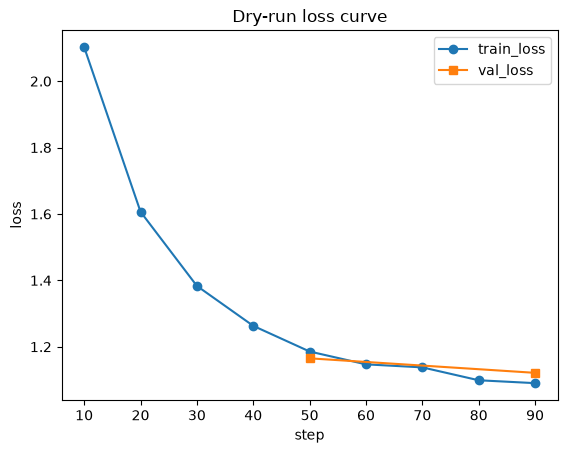

In [29]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train = [x for x in log if "loss" in x]
val   = [x for x in log if "eval_loss" in x]

plt.plot([x["step"] for x in train], [x["loss"] for x in train], "o-", label="train_loss")
plt.plot([x["step"] for x in val],   [x["eval_loss"] for x in val], "s-", label="val_loss")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Dry-run loss curve")
plt.show()

In [30]:
trainer.save_model("/workspace/adapter_qwen_cot_full")
tokenizer.save_pretrained("/workspace/adapter_qwen_cot_full")

('/workspace/adapter_qwen_cot_full/tokenizer_config.json',
 '/workspace/adapter_qwen_cot_full/chat_template.jinja',
 '/workspace/adapter_qwen_cot_full/tokenizer.json')